In [1]:
import yfinance as yf
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

TICKERS = [
    "LLY", "NVO", "SNY", "VRTX", "OTSKY",
    "CRSP", "SANA", "EVO", "LCTX", "HUMA",
    "GNPX", "IPSC", "SABS", "SEOVF", "NCEL",
    "FLUI.ST", "NXTCL.ST", "IMCR", "CELZ", "ELDN",
    "ADOC.PA"
]

SPX_TICKER    = "^GSPC"
SECTOR_TICKER = "XLV"

# ── Set the "as of" date you want ────────────────────────────────────────────
AS_OF = pd.Timestamp("2026-04-06", tz="America/New_York")
END   = (AS_OF + pd.Timedelta(days=1)).strftime("%Y-%m-%d")


# ── Weekly return: close 5 trading days ago → latest close ──────────────────
def get_weekly_return(hist: pd.DataFrame):
    """
    True 5-trading-day return: price[t] / price[t-5] - 1.
    Requires at least 6 rows (today + 5 prior days).
    """
    if hist is None or hist.empty or len(hist) < 6:
        return None
    last6 = hist.tail(6)
    return last6["Close"].iloc[-1] / last6["Close"].iloc[0] - 1


# ── YTD return: last close of prior year → latest close ─────────────────────
def get_ytd_return(hist: pd.DataFrame, as_of: pd.Timestamp):
    """
    Uses the last trading day of the prior calendar year as the base,
    matching how Bloomberg / most data providers calculate YTD.
    """
    if hist is None or hist.empty:
        return None
    year = as_of.year
    prior_year = hist[hist.index.year == year - 1]
    current_year = hist[hist.index.year == year]
    if prior_year.empty or current_year.empty:
        return None
    base  = float(prior_year["Close"].iloc[-1])
    latest = float(current_year["Close"].iloc[-1])
    return latest / base - 1


# ── Market cap classification ────────────────────────────────────────────────
def classify_market_cap(market_cap_usd: float):
    if market_cap_usd is None:
        return None
    if market_cap_usd >= 10e9:
        return "Large-cap"
    elif market_cap_usd >= 2e9:
        return "Mid-cap"
    elif market_cap_usd >= 300e6:
        return "Small-cap"
    else:
        return "Micro-cap"


# ── History fetch capped at AS_OF ────────────────────────────────────────────
def history_as_of(ticker: yf.Ticker, lookback_days: int = 420):
    """
    Fetch ~420 calendar days of daily history and trim to AS_OF.
    420 days covers 252+ trading days comfortably for the 52-week range.
    """
    start = (AS_OF - pd.Timedelta(days=lookback_days)).strftime("%Y-%m-%d")
    try:
        hist = ticker.history(start=start, end=END, interval="1d")
    except Exception as e:
        print(f"  [WARN] history fetch failed: {e}")
        return pd.DataFrame()
    if hist is None or hist.empty:
        return pd.DataFrame()
    return hist[hist.index <= AS_OF]


# ── FX helpers ───────────────────────────────────────────────────────────────
_FX_CACHE: dict = {}

def get_fx_to_usd_asof(ccy: str) -> float | None:
    ccy = (ccy or "").upper()
    if ccy in ("USD", ""):
        return 1.0
    if ccy in _FX_CACHE:
        return _FX_CACHE[ccy]
    fx_tkr = f"{ccy}USD=X"
    fx_hist = history_as_of(yf.Ticker(fx_tkr), lookback_days=30)
    if fx_hist is None or fx_hist.empty:
        print(f"  [WARN] FX rate not found for {ccy}, will be None")
        _FX_CACHE[ccy] = None
        return None
    fx = float(fx_hist["Close"].iloc[-1])
    _FX_CACHE[ccy] = fx
    return fx

def to_usd(value, fx) -> float | None:
    if value is None or fx is None:
        return None
    return float(value) * float(fx)


# ── Benchmarks ───────────────────────────────────────────────────────────────
print("Fetching benchmarks...")
spx_hist = history_as_of(yf.Ticker(SPX_TICKER))
xlv_hist = history_as_of(yf.Ticker(SECTOR_TICKER))
spx_week_ret = get_weekly_return(spx_hist) or 0.0
xlv_week_ret = get_weekly_return(xlv_hist) or 0.0
print(f"  S&P 500 weekly: {spx_week_ret*100:.2f}%  |  XLV weekly: {xlv_week_ret*100:.2f}%")


# ── Per-ticker metrics ───────────────────────────────────────────────────────
def get_metrics(ticker: str) -> dict:
    print(f"  {ticker}...")
    t = yf.Ticker(ticker)

    try:
        info = t.info or {}
    except Exception as e:
        print(f"  [WARN] {ticker}: info fetch failed ({e})")
        info = {}

    local_ccy = info.get("currency")
    fx_to_usd = get_fx_to_usd_asof(local_ccy)

    hist = history_as_of(t)

    if not hist.empty:
        close_local    = float(hist["Close"].iloc[-1])
        hist_52w       = hist.tail(252)
        low_52w_local  = float(hist_52w["Low"].min())
        high_52w_local = float(hist_52w["High"].max())
        week_ret       = get_weekly_return(hist)
        ytd_ret        = get_ytd_return(hist, AS_OF)

        # Volume — warn if looks unreliable (common with non-US OTC tickers)
        vol_series = hist["Volume"].replace(0, pd.NA)
        vol_100d   = vol_series.tail(100).mean()
        vol_week   = vol_series.tail(5).mean()
        rel_vol    = (vol_week / vol_100d) if (pd.notna(vol_100d) and vol_100d > 0) else None

        if ticker in ("FLUI.ST", "NXTCL.ST") and (rel_vol is None or vol_100d < 100):
            print(f"  [WARN] {ticker}: volume data may be unreliable (vol_100d={vol_100d})")
    else:
        print(f"  [WARN] {ticker}: no price history returned")
        close_local = low_52w_local = high_52w_local = None
        week_ret = ytd_ret = None
        vol_100d = vol_week = rel_vol = None

    if week_ret is not None:
        excess_spx = (week_ret - spx_week_ret) * 100
        excess_xlv = (week_ret - xlv_week_ret) * 100
    else:
        excess_spx = excess_xlv = None

    market_cap_local = info.get("marketCap")
    market_cap_usd   = to_usd(market_cap_local, fx_to_usd)

    return {
        "As Of":                                   AS_OF.strftime("%Y-%m-%d"),
        "Ticker":                                  ticker,
        "Company Name":                            info.get("shortName"),
        "Industry Group":                          info.get("industry"),
        "Local Currency":                          local_ccy,
        "FX to USD (as-of)":                       fx_to_usd,
        "Market Cap (USD)":                        market_cap_usd,
        "Market Cap Group":                        classify_market_cap(market_cap_usd),
        "Closing Price (USD)":                     to_usd(close_local, fx_to_usd),
        "52 Week Low (USD)":                       to_usd(low_52w_local, fx_to_usd),
        "52 Week High (USD)":                      to_usd(high_52w_local, fx_to_usd),
        "1-Week Return (Past 5 Trading Days)":     week_ret,
        "Excess Weekly Return vs. S&P 500 (ppt)":  excess_spx,
        "Excess Weekly Return vs. XLV (ppt)":      excess_xlv,
        "Total Return (YTD)":                      ytd_ret,
        "Average Daily Volume (100D)":             vol_100d,
        "Avg Daily Volume (Last 5 Days)":          vol_week,
        "Relative Volume (Last 5D vs 100D)":       rel_vol,
        "EPS (Basic)":                             info.get("trailingEps"),
        "P/E (Trailing)":                          info.get("trailingPE"),
        "Current Ratio":                           info.get("currentRatio"),
    }


# ── Run ──────────────────────────────────────────────────────────────────────
print("\nFetching portfolio metrics...")
rows = []
for tkr in TICKERS:
    rows.append(get_metrics(tkr))

df = pd.DataFrame(rows)

# Sanity check: flag any tickers with missing price or return data
missing = df[df["Closing Price (USD)"].isna()]["Ticker"].tolist()
if missing:
    print(f"\n[WARN] No price data for: {missing}")

no_ytd = df[df["Total Return (YTD)"].isna()]["Ticker"].tolist()
if no_ytd:
    print(f"[WARN] No YTD return for: {no_ytd}")

outfile = f"jdca_weekly_metrics_asof_{AS_OF.strftime('%Y-%m-%d')}.xlsx"
df.to_excel(outfile, index=False)
print(f"\nDone. Saved to {outfile}")
print(df[["Ticker","Closing Price (USD)","1-Week Return (Past 5 Trading Days)","Total Return (YTD)"]].to_string(index=False))




Fetching benchmarks...
  S&P 500 weekly: 3.38%  |  XLV weekly: 2.05%

Fetching portfolio metrics...
  LLY...
  NVO...
  SNY...
  VRTX...
  OTSKY...
  CRSP...
  SANA...
  EVO...
  LCTX...
  HUMA...
  GNPX...
  IPSC...
  SABS...
  SEOVF...
  NCEL...
  FLUI.ST...
  NXTCL.ST...
  IMCR...
  CELZ...
  ELDN...
  ADOC.PA...

Done. Saved to jdca_weekly_metrics_asof_2026-04-06.xlsx
  Ticker  Closing Price (USD)  1-Week Return (Past 5 Trading Days)  Total Return (YTD)
     LLY           928.929016                             0.057717           -0.134180
     NVO            37.244999                             0.071336           -0.241137
     SNY            47.849998                             0.022873           -0.012588
    VRTX           437.100006                             0.009306           -0.035865
   OTSKY            35.799999                             0.034981            0.263678
    CRSP            50.000000                             0.092896           -0.046529
    SANA        

In [4]:
import yfinance as yf
import pandas as pd

tickers = {
    "SP500": "^GSPC",
    "XLV": "XLV"
}

# Pull ~2 months to safely cover 4 full weeks
data = yf.download(
    list(tickers.values()),
    period="2mo",
    interval="1d",
    auto_adjust=True,
    progress=False
)["Close"]

# Convert daily prices to weekly (Friday close)
weekly_prices = data.resample("W-FRI").last()

weekly_returns = (
    data
    .resample("W-FRI")
    .last()
    .pct_change()
    .dropna()
    .tail(4)
)

# Relabel index to match tracker dates (Monday labels)
weekly_returns.index = pd.to_datetime([
    "2025-11-24",
    "2025-12-01",
    "2025-12-08",
    "2025-12-15"
])

weekly_returns


Ticker,XLV,^GSPC
2025-11-24,0.019662,0.037271
2025-12-01,-0.027846,0.003111
2025-12-08,0.002088,0.004454
2025-12-15,0.013413,-0.012910


In [2]:
ticker = "NVO"
data = yf.download(ticker, period="1mo", interval="1d")[['Volume']]

# Group by week
data['Week'] = data.index.to_period('W')
weekly_avg = data.groupby('Week')['Volume'].mean().reset_index()
weekly_avg.columns = ['Week', 'Weekly_Avg_Volume']
print(weekly_avg.tail())

/var/folders/kl/1t4_wb0x6wn6kzwk0w_6dg0r0000gn/T/ipykernel_87700/4107187295.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="1mo", interval="1d")[['Volume']]
[*********************100%***********************]  1 of 1 completed

                    Week  Weekly_Avg_Volume
0  2025-10-06/2025-10-12         11446720.0
1  2025-10-13/2025-10-19          9611720.0
2  2025-10-20/2025-10-26          9665740.0
3  2025-10-27/2025-11-02         14607760.0
4  2025-11-03/2025-11-09         19758582.5


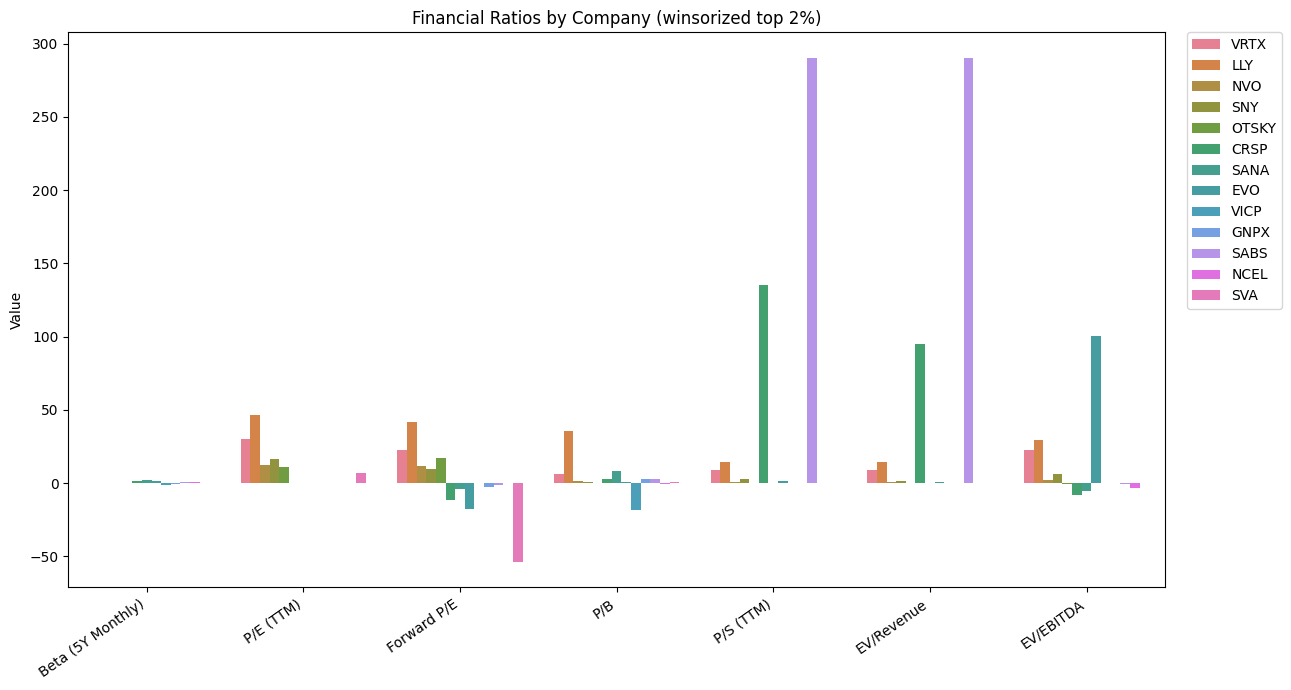

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# --- 4) Melt for plotting; drop NaNs so seaborn doesn't plot 0s ---------
# Order metrics (optional)
melted_df = df.melt(id_vars=["Ticker"], value_vars=ratio_cols, var_name="Metric", value_name="Value")
melted_df = melted_df.dropna(subset=["Value"])
metric_order = ratio_cols

#Winsorize top 2%
from scipy.stats import mstats
melted_df["Value"] = mstats.winsorize(melted_df["Value"], limits=[0, 0.02])

# --- 5) Plot 1: Ratios by company (grouped bar) -------------------------
plt.figure(figsize=(13, 7))
sns.barplot(data=melted_df, x="Metric", y="Value", hue="Ticker", order=metric_order)
plt.xticks(rotation=35, ha="right")
plt.title("Financial Ratios by Company (winsorized top 2%)")
plt.xlabel("")
plt.ylabel("Value")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

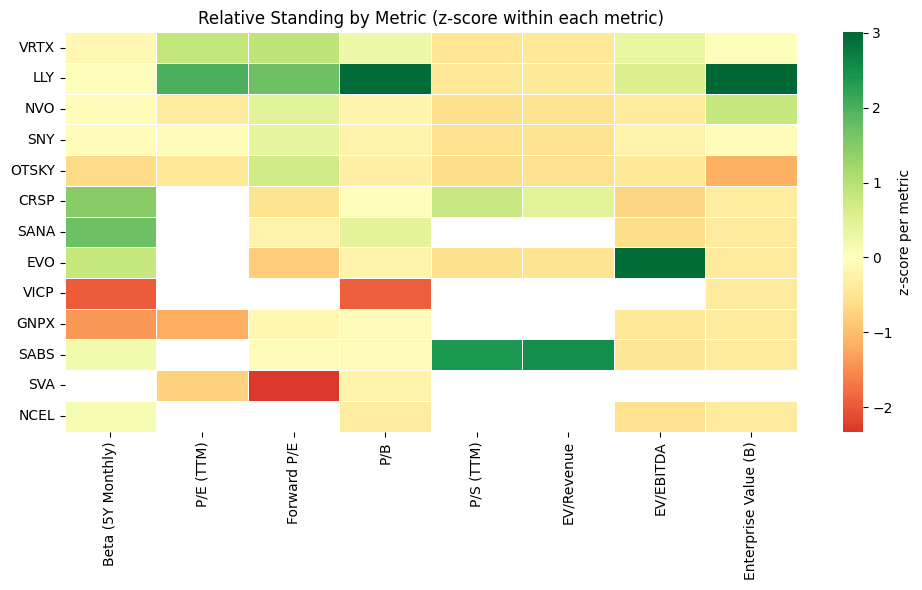

In [9]:
metrics = ratio_cols + ["Enterprise Value (B)"]

Z = (df.set_index("Ticker")[metrics]
       .apply(lambda col: (col - col.mean())/col.std(ddof=0), axis=0))

plt.figure(figsize=(10,6))
sns.heatmap(Z, cmap="RdYlGn", center=0, annot=False, linewidths=0.4,
            cbar_kws={"label":"z-score per metric"}, mask=Z.isna())
plt.title("Relative Standing by Metric (z-score within each metric)")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout(); plt.show()


/var/folders/kl/1t4_wb0x6wn6kzwk0w_6dg0r0000gn/T/ipykernel_4760/619453365.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp, x=metric, y="Ticker", palette="crest")


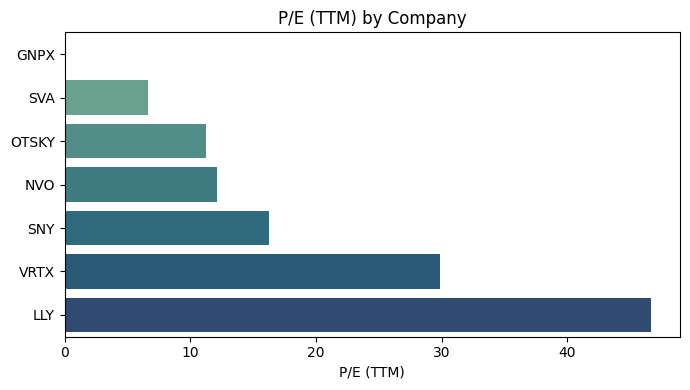

/var/folders/kl/1t4_wb0x6wn6kzwk0w_6dg0r0000gn/T/ipykernel_4760/619453365.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp, x=metric, y="Ticker", palette="crest")


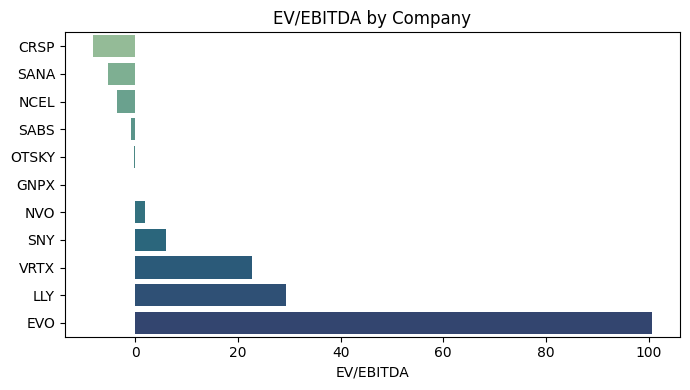

In [11]:
key_metrics = ["P/E (TTM)", "EV/EBITDA"]
for metric in key_metrics:
    plt.figure(figsize=(7,4))
    temp = df[["Ticker", metric]].dropna().sort_values(metric)
    sns.barplot(data=temp, x=metric, y="Ticker", palette="crest")
    plt.title(f"{metric} by Company")
    plt.xlabel(metric)
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


In [12]:
styled = (
    df.set_index("Ticker")[metrics]
    .style.background_gradient(cmap="YlGn", axis=0)
    .format("{:.2f}")
    .set_caption("Key Valuation Metrics by Company")
)
styled


,Beta (5Y Monthly),P/E (TTM),Forward P/E,P/B,P/S (TTM),EV/Revenue,EV/EBITDA
Ticker,,,,,,,
VRTX,0.32,29.82,22.58,6.22,9.18,8.76,22.79
LLY,0.39,46.63,41.98,35.81,14.33,14.22,29.40
NVO,0.35,12.13,11.48,1.24,0.67,0.94,1.85
SNY,0.37,16.24,9.93,0.82,2.65,1.59,5.91
OTSKY,-0.13,11.22,17.10,0.01,0.01,-0.08,-0.34
CRSP,1.72,nan,-11.23,2.92,135.23,95.26,-8.29
SANA,1.95,nan,-4.33,7.97,nan,nan,-5.21
EVO,1.15,nan,-17.75,0.71,1.57,1.05,100.66
VICP,-1.29,nan,nan,-18.29,nan,nan,nan


In [13]:
styled.to_html("valuation_scorecard.html")

In [ ]:
#